# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [2]:
!git clone https://github.com/SAJLENDRAPANDEY/flyrank-ml-internship-starter.git

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 292, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 292 (delta 138), reused 64 (delta 64), pack-reused 86 (from 1)
Receiving objects: 100% (292/292), 3.69 MiB | 6.02 MiB/s, done.
Resolving deltas: 100% (144/144), done.


In [4]:
%cd /content/flyrank-ml-internship-starter

/content/flyrank-ml-internship-starter


Dataset shape: (30000, 44)


,count,mean,std,min,25%,50%,75%,max
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.00,104.00,373.0
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0


,median,mean,skewness
days_since_last_update,20.00,46.098300,1.161283
impressions_90d,731.00,5200.366300,11.384919
ctr,0.07,0.510733,17.444252


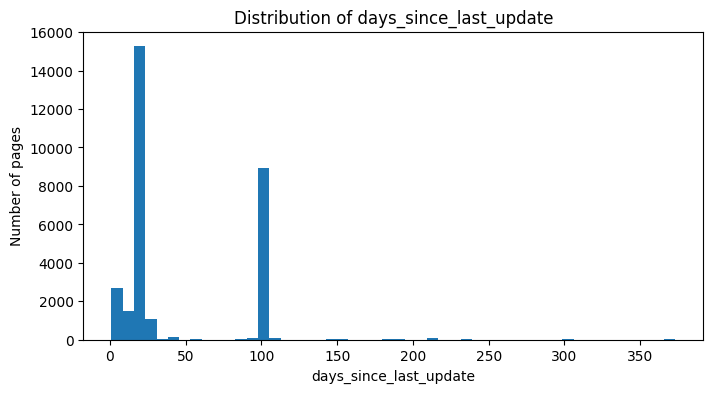

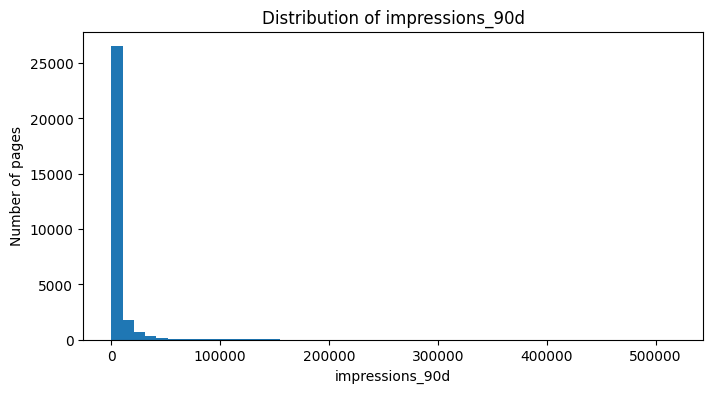

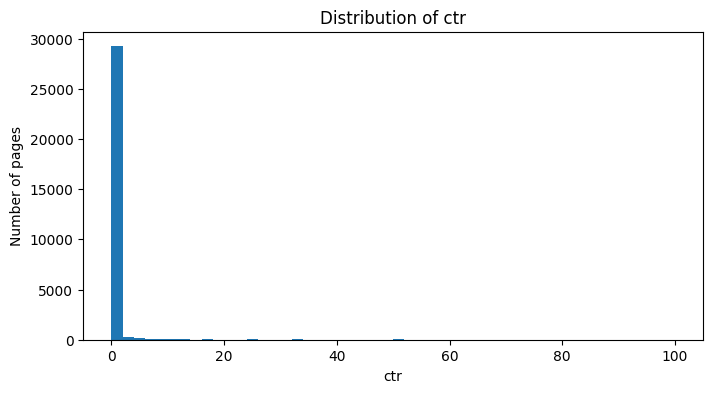

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the starter dataset
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)

# Key baseline signals
key_fields = [
    "days_since_last_update",
    "impressions_90d",
    "ctr"
]

# Basic distribution statistics
display(df[key_fields].describe().T)

# Median and skewness
distribution_summary = pd.DataFrame({
    "median": df[key_fields].median(),
    "mean": df[key_fields].mean(),
    "skewness": df[key_fields].skew()
})

display(distribution_summary)

# Histograms
for column in key_fields:
    plt.figure(figsize=(8, 4))
    plt.hist(df[column].dropna(), bins=50)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of pages")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [6]:
# Create the decline label from the documented label definition.
# 1 = declining, 0 = not declining
df["is_declining_label"] = (
    df["trend_direction"].eq("down").astype(int)
)

print("Declining rate:")
print(df["is_declining_label"].mean())

# ---------------------------------------------------------
# Signal #1: Older pages should be more likely to decline
# ---------------------------------------------------------

age_groups = pd.qcut(
    df["days_since_last_update"],
    q=4,
    duplicates="drop"
)

signal_1 = (
    df.groupby(age_groups, observed=False)["is_declining_label"]
      .agg(["mean", "count"])
)

print("Signal #1 — Decline rate by days since last update:")
display(signal_1)

# ---------------------------------------------------------
# Signal #2: Higher impressions should indicate more value
# ---------------------------------------------------------
# We test whether declining pages have different impression
# levels, without claiming causality.

impression_groups = pd.qcut(
    df["impressions_90d"],
    q=4,
    duplicates="drop"
)

signal_2 = (
    df.groupby(impression_groups, observed=False)["is_declining_label"]
      .agg(["mean", "count"])
)

print("Signal #2 — Decline rate by 90-day impressions:")
display(signal_2)

# ---------------------------------------------------------
# Signal #3: Lower CTR should be associated with decline
# ---------------------------------------------------------

ctr_groups = pd.qcut(
    df["ctr"],
    q=4,
    duplicates="drop"
)

signal_3 = (
    df.groupby(ctr_groups, observed=False)["is_declining_label"]
      .agg(["mean", "count"])
)

print("Signal #3 — Decline rate by CTR:")
display(signal_3)

Declining rate:
0.5420666666666667
Signal #1 — Decline rate by days since last update:


,mean,count
days_since_last_update,,
"(0.999, 20.0]",0.538888,15866
"(20.0, 104.0]",0.545599,13816
"(104.0, 373.0]",0.547170,318


Signal #2 — Decline rate by 90-day impressions:


,mean,count
impressions_90d,,
"(0.999, 81.0]",0.376116,7503
"(81.0, 731.0]",0.604614,7499
"(731.0, 3615.25]",0.625634,7498
"(3615.25, 517715.0]",0.562000,7500


Signal #3 — Decline rate by CTR:


,mean,count
ctr,,
"(-0.001, 0.07]",0.523910,15224
"(0.07, 0.29]",0.604825,7503
"(0.29, 100.0]",0.515331,7273


### Signal #1 — Days since last update

The observed decline rate was 53.89% for the newest group, 54.56% for the middle group, and 54.72% for the oldest group. The increase is small and does not provide strong evidence that older pages are substantially more likely to decline.

**Verdict: MIXED**

### Signal #2 — 90-day impressions

The lowest-impression group had a 37.61% decline rate, while the next two groups had higher rates of 60.46% and 62.56%. The highest-impression group fell to 56.20%, so the relationship is not consistently increasing across all groups.

**Verdict: MIXED**

### Signal #3 — CTR

The decline rate was 52.39% in the lowest-CTR group, increased to 60.48% in the middle group, and then decreased to 51.53% in the highest-CTR group. This does not show a consistent relationship between lower CTR and decline.

**Verdict: MIXED**


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [7]:
# Flag-linked test: STALE_CONTENT
# Baseline rule:
# days_since_last_update >= 180 -> STALE_CONTENT

df["stale_content"] = (
    df["days_since_last_update"] >= 180
)

# Compare decline rate for stale vs non-stale pages
flag_test = (
    df.groupby("stale_content")["is_declining_label"]
      .agg(["mean", "count"])
      .rename(columns={
          "mean": "decline_rate",
          "count": "page_count"
      })
)

print("STALE_CONTENT flag test:")
display(flag_test)

# Calculate the observed difference
decline_rate_stale = df.loc[
    df["stale_content"],
    "is_declining_label"
].mean()

decline_rate_not_stale = df.loc[
    ~df["stale_content"],
    "is_declining_label"
].mean()

difference = decline_rate_stale - decline_rate_not_stale

print(
    f"Observed decline-rate difference "
    f"(stale - not stale): {difference:.4f}"
)

STALE_CONTENT flag test:


,decline_rate,page_count
stale_content,,
False,0.542480,29826
True,0.471264,174


Observed decline-rate difference (stale - not stale): -0.0712


### Flag-linked test: STALE_CONTENT

The baseline marks pages as `STALE_CONTENT` when `days_since_last_update >= 180`. In the observed dataset, stale pages had a decline rate of 47.13%, compared with 54.25% for non-stale pages. The observed difference was -7.12 percentage points, so the data does not support the assumption that pages not updated for 180 days are more likely to be declining.

**Verdict: OPPOSITE**


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [8]:
# Flag-linked test: STALE_CONTENT
# Baseline flag = pages not updated for 180+ days

df["stale_content"] = (
    df["days_since_last_update"] >= 180
)

flag_test = (
    df.groupby("stale_content")["is_declining_label"]
      .agg(["mean", "count"])
      .rename(columns={
          "mean": "decline_rate",
          "count": "page_count"
      })
)

print("STALE_CONTENT flag test:")
display(flag_test)

# Difference in observed decline rate
decline_rate_stale = df.loc[
    df["stale_content"], "is_declining_label"
].mean()

decline_rate_not_stale = df.loc[
    ~df["stale_content"], "is_declining_label"
].mean()

difference = decline_rate_stale - decline_rate_not_stale

print(
    f"Observed decline-rate difference "
    f"(stale - not stale): {difference:.4f}"
)

STALE_CONTENT flag test:


,decline_rate,page_count
stale_content,,
False,0.542480,29826
True,0.471264,174


Observed decline-rate difference (stale - not stale): -0.0712


### What this means in practice

The signal audit shows that the three baseline signals have mixed relationships with observed decline, while the `STALE_CONTENT` rule is not supported by the data and shows the opposite pattern in this sample. The content team should therefore treat these signals as directional decision-support indicators rather than automatic refresh rules, and prioritize pages using a model or review process that can consider multiple signals together.


## Self-check

Before you submit, confirm each line honestly:

- [*] Every section above is filled — markdown thinking AND the code that backs it
- [*] The notebook runs top to bottom with no errors (Runtime → Run all)
- [*] No client names, URLs, or private queries anywhere
- [*] My claims use careful words: observed, measured, directional, decision-support
- [*] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.